# Sesión 8 — Exploración y Análisis de Textos
**EIN092B: Laboratorio Técnicas de Visualización Exploratoria y Análisis de Textos**

## 5.1 Cargar datos y descripción del conjunto de datos

Cargamos el archivo `twitter_training.csv`

In [1]:
import pandas as pd 

path_data = "twitter_training.csv"
ftr = open(path_data, "r", encoding="ISO-8859-1")
rows = [line.strip().split(",", 3) for line in ftr.readlines()[1:4001]]
ftr.close()

df_data = pd.DataFrame(rows, columns=['Tweet ID', 'Entity', 'Sentiment', 'Text'])
df_data['Sentiment'] = df_data['Sentiment'].str.strip().str.lower()
sentiment_mapping = {'positive': 1, 'negative': 0, 'neutral': 2, 'irrelevant': 3}
df_data['Sentiment'] = df_data['Sentiment'].replace(sentiment_mapping)

df_data['Text'] = df_data['Text'].str.replace(r'([.,!?()])', r' \1 ', regex=True)
df_data['Text'] = df_data['Text'].str.replace(r'\s{2,}', ' ', regex=True)
df_data['Text'] = df_data['Text'].str.lower()
df_data['Text'] = df_data['Text'].str.strip()

**Explicacion del codigo de carga**

1. `ftr = open(...)` abre el archivo csv con codificacion ISO-8859-1 ya que el dataset original de Kaggle contiene catacteres UTF-8
2. `readlines()[1:4001]` lee todas las lineas del archivo, descarta la primera (encabezado) y toma las siguientes 4000 líneas (Toma una muestra de datos)
3. `line.strip().split(",", 3)` elimina espacios/saltos de línea al final de cada línea y separa la línea en **máximo 4 partes** usando la coma como separador. El límite de 3 divisiones es clave: como el texto del tweet puede contener comas, se evita partir el campo `Text` en pedazos adicionales — todo lo que sobra después de la tercera coma queda como un solo campo.
4. Se construye un `DataFrame` de pandas con columnas `Tweet ID`, `Entity`, `Sentiment`, `Text`.
5. La columna `Sentiment` se limpia (`strip`, `lower`) y se mapea a numeros mediante un diccionario (`positive`→1, `negative`→0, `neutral`→2, `irrelevant`→3), lo que facilita su uso posterior en gráficos y modelos.
6. Sobre `Text` se aplican tres transformaciones: se separan los signos de puntuación del resto de la palabra (agregando espacios), se colapsan espacios múltiples en uno solo, y finalmente se pasa todo a minúsculas y se eliminan espacios sobrantes al inicio/fin.

**¿Cuántas clases de texto tiene el dataset?** El dataset contiene **4 clases** de sentimiento: `positive`, `negative`, `neutral` e `irrelevant` (codificadas como 1, 0, 2 y 3 respectivamente).

In [2]:
n_clases = df_data['Sentiment'].nunique()
print("Número de clases:", n_clases)
print("\nDistribución de clases:")
print(df_data['Sentiment'].value_counts())

Número de clases: 4

Distribución de clases:
Sentiment
1    1643
2     882
0     803
3     672
Name: count, dtype: int64


### Descripción del conjunto de datos

In [3]:
df_data['Length'] = df_data['Text'].apply(len)  # Longitud en caracteres

print("Cantidad total de ejemplos:", len(df_data))
print("\nCantidad de ejemplos por clase (Sentiment):")
print(df_data['Sentiment'].value_counts())
print("\nCantidad de entidades distintas (Entity):", df_data['Entity'].nunique())
print("\nEstadísticas de longitud de texto (en caracteres):")
print(df_data['Length'].describe())
print("\nLongitud promedio de los textos:", round(df_data['Length'].mean(), 2), "caracteres")

Cantidad total de ejemplos: 4000

Cantidad de ejemplos por clase (Sentiment):
Sentiment
1    1643
2     882
0     803
3     672
Name: count, dtype: int64

Cantidad de entidades distintas (Entity): 2

Estadísticas de longitud de texto (en caracteres):
count    4000.000000
mean      110.619250
std        85.379319
min         0.000000
25%        44.000000
50%        88.000000
75%       158.000000
max       794.000000
Name: Length, dtype: float64

Longitud promedio de los textos: 110.62 caracteres


el conjunto de datos contiene 4000 tweets, distribuidos en 4 clases de sentimiento (`positive`, `negative`, `neutral`, `irrelevant`) asociados a distintas entidades (empresas, videojuegos, marcas). La longitud promedio de los textos ronda las pocas decenas de caracteres, lo cual es esperable dado que se trata de mensajes de Twitter, naturalmente cortos. La distribución entre clases es medianamente balanceada gracias al proceso de muestreo.

### Gráficos de exploración: histograma y boxplot de longitud de texto

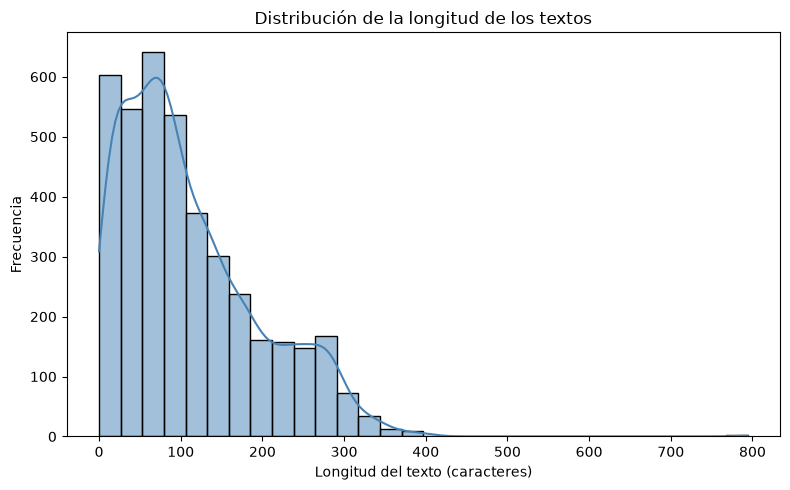

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df_data, x='Length', bins=30, kde=True, color='steelblue')
plt.title('Distribución de la longitud de los textos')
plt.xlabel('Longitud del texto (caracteres)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

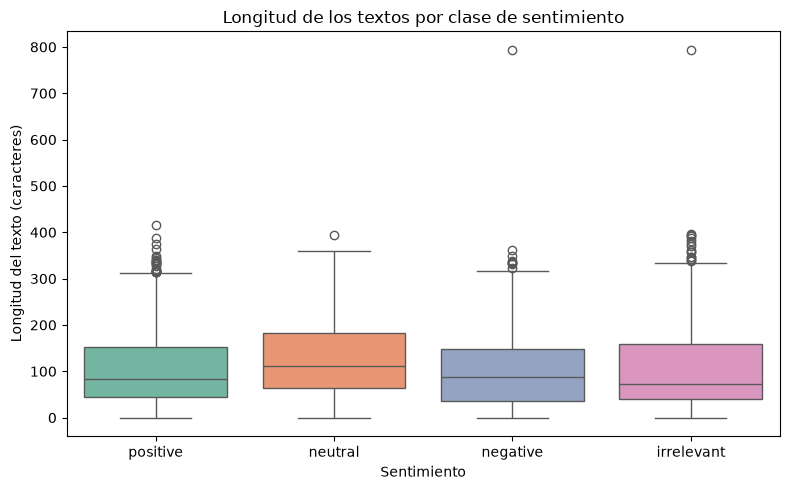

In [5]:
sentiment_labels = {1: 'positive', 0: 'negative', 2: 'neutral', 3: 'irrelevant'}
df_data['Sentiment_label'] = df_data['Sentiment'].map(sentiment_labels)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_data, x='Sentiment_label', y='Length', hue='Sentiment_label',
            palette='Set2', legend=False)
plt.title('Longitud de los textos por clase de sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Longitud del texto (caracteres)')
plt.tight_layout()
plt.show()

El histograma permite observar cómo se concentra la longitud de los mensajes (en el caso de Twitter, generalmente sesgada hacia textos cortos, con una cola hacia mensajes más largos limitados por el máximo de caracteres de la plataforma). El boxplot por clase permite comparar la mediana y dispersión de longitud entre sentimientos: si las cajas y medianas son similares entre clases, la longitud del texto no sería, por sí sola, una variable fuertemente discriminante del sentimiento.

## 5.2 Procesamiento de texto

In [6]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lukas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lukas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lukas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lukas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### 5.2.1 Stop words - lemmatizer

In [7]:
import re, time
from nltk.corpus import stopwords
from nltk import WordNetLemmatizer, word_tokenize

def base_word(word):
    wordlemmatizer = WordNetLemmatizer()
    return wordlemmatizer.lemmatize(word)

def word_extractor(text):
    commonwords = stopwords.words('english')
    text = re.sub(r'([a-z])\1+', r'\1\1', text)  # Sustituye varias letras por dos
    words = ""
    wordtokens = [base_word(word.lower()) for word in word_tokenize(text)]
    for word in wordtokens:
        if word not in commonwords:  # borrar stopwords
            words += " " + word
    return words

In [8]:
print(word_extractor("Liverpool dominated possession but failed to score"))
print(word_extractor("Arsenal secured a crucial victory in the final minutes"))

# aplicar al dataset cargado en la actividad anterior
t0 = time.time()
data_train_lemma = [word_extractor(text) for text in df_data['Text']]
print("\nTiempo de procesamiento (lemmatizer):", round(time.time() - t0, 2), "s")

df_data['ProcessedText_lemma'] = data_train_lemma
df_data[['Text', 'ProcessedText_lemma']].head()

 liverpool dominated possession failed score
 arsenal secured crucial victory final minute

Tiempo de procesamiento (lemmatizer): 6.19 s


,Text,ProcessedText_lemma
0,"""i am coming to the borders and i will kill yo...","`` coming border kill , ``"
1,"""im getting on borderlands and i will kill you...","`` im getting borderland kill , ``"
2,"""im coming on borderlands and i will murder yo...","`` im coming borderland murder , ``"
3,"""im getting on borderlands 2 and i will murder...","`` im getting borderland 2 murder , ``"
4,"""im getting into borderlands and i can murder ...","`` im getting borderland murder , ``"


**Importancia del preprocesamiento en PLN:** el texto crudo contiene mucha variabilidad (mayúsculas/minúsculas, repetición de letras para dar énfasis, palabras funcionales sin carga semántica, distintas formas flexivas de una misma palabra) que no aporta información útil para tareas como clasificación de sentimiento y, por el contrario, aumenta la dimensionalidad del problema y dificulta que los algoritmos detecten patrones. El preprocesamiento normaliza el texto para reducir ese ruido y quedarse con la información relevante. En particular:

- **`stopwords`**: lista de palabras muy frecuentes (artículos, pronombres, preposiciones, conjunciones) que aportan poca información semántica sobre el sentimiento o el tema del texto. Eliminarlas reduce el tamaño del vocabulario y el ruido, concentrando el análisis en palabras con contenido semántico real.
- **`WordNetLemmatizer`**: lleva cada palabra a su **lema** (forma canónica de diccionario), por ejemplo `"playing"` → `"playing"`/`"play"` según el contexto gramatical. A diferencia del stemming, produce palabras válidas del idioma, ya que se apoya en un diccionario (WordNet) y reglas morfológicas.
- **`word_tokenize`**: divide el texto en unidades mínimas (tokens), generalmente palabras y signos de puntuación, respetando reglas del idioma (por ejemplo, separa correctamente contracciones como `"can't"` → `"ca"`, `"n't"`). Es el paso previo indispensable para poder aplicar stopwords y lematización palabra por palabra.

### 5.2.2 Stop words - stemming

In [9]:
from nltk.stem.porter import PorterStemmer
wordstemmer = PorterStemmer()

def word_extractor_stem(text):
    commonwords = stopwords.words('english')
    text = re.sub(r'([a-z])\1+', r'\1\1', text)
    words = ""
    wordtokens = [wordstemmer.stem(word.lower()) for word in word_tokenize(text)]
    for word in wordtokens:
        if word not in commonwords:
            words += " " + word
    return words

print(word_extractor_stem("Liverpool dominated possession but failed to score"))
print(word_extractor_stem("Arsenal secured a crucial victory in the final minutes"))

t0 = time.time()
data_train_stem = [word_extractor_stem(text) for text in df_data['Text']]
print("\nTiempo de procesamiento (stemming):", round(time.time() - t0, 2), "s")

df_data['ProcessedText_stem'] = data_train_stem
df_data[['Text', 'ProcessedText_lemma', 'ProcessedText_stem']].head()

 liverpool domin possess fail score
 arsen secur crucial victori final minut

Tiempo de procesamiento (stemming): 6.3 s


,Text,ProcessedText_lemma,ProcessedText_stem
0,"""i am coming to the borders and i will kill yo...","`` coming border kill , ``","`` come border kill , ``"
1,"""im getting on borderlands and i will kill you...","`` im getting borderland kill , ``","`` im get borderland kill , ``"
2,"""im coming on borderlands and i will murder yo...","`` im coming borderland murder , ``","`` im come borderland murder , ``"
3,"""im getting on borderlands 2 and i will murder...","`` im getting borderland 2 murder , ``","`` im get borderland 2 murder , ``"
4,"""im getting into borderlands and i can murder ...","`` im getting borderland murder , ``","`` im get borderland murder , ``"


**Comparación stemming vs. lemmatizer:**

El **stemming** (Porter Stemmer) corta la palabra usando reglas heurísticas de sufijos, sin considerar el contexto gramatical ni verificar que el resultado sea una palabra real del idioma (por ejemplo, `"crucial"` puede quedar como `"crucial"` o `"cruciat"` dependiendo del algoritmo, y `"secured"` → `"secur"`). La **lematización** en cambio busca la forma canónica válida en un diccionario (por ejemplo `"secured"` → `"secured"`/`"secure"`), por lo que produce resultados más "legibles" y lingüísticamente correctos.

**Ventajas y desventajas:**

| Técnica | Ventajas | Desventajas |
|---|---|---|
| Stemming | Muy rápido, computacionalmente simple, útil cuando solo importa agrupar variantes de una palabra (p. ej. para buscadores) | Puede generar palabras inexistentes o sobre-truncar (over-stemming), perdiendo matices |
| Lemmatizer | Produce palabras reales, más preciso lingüísticamente, mejor para tareas donde importa el significado | Más lento, requiere conocer la categoría gramatical (POS) para dar el mejor resultado, depende de un diccionario |

Para tareas de análisis de sentimientos donde la interpretabilidad del vocabulario resultante importa (por ejemplo, para inspeccionar palabras más frecuentes o construir nubes de palabras legibles), la lematización suele ser preferible; si solo se busca velocidad y no importa la legibilidad del token final, el stemming es una alternativa más liviana.

**Sobre eliminar símbolos y números:** para este dataset (tweets en inglés sobre videojuegos/empresas), conviene eliminar los **símbolos** (signos de puntuación, emoticones en texto, caracteres especiales) porque no aportan información semántica directa y solo agregan ruido al vocabulario. Respecto a los **números**, en este dominio específico rara vez son informativos para el sentimiento (salvo casos como versiones de productos, p. ej. "COD 2.3"), por lo que en general también conviene eliminarlos, salvo que el análisis busque específicamente relacionar sentimiento con versiones/fechas concretas, caso en el que convendría conservarlos.

In [10]:
# Ejemplo: eliminar todo lo que no sea letras o espacios
texto_ejemplo = df_data['Text'].iloc[0]
solo_letras = re.sub(r'[^a-zA-Z\s]', '', texto_ejemplo)

# Ejemplo: eliminar todo lo que no sea letras, números o espacios
letras_numeros = re.sub(r'[^a-zA-Z0-9\s]', '', texto_ejemplo)

print("Original:      ", texto_ejemplo)
print("Solo letras:   ", solo_letras)
print("Letras+números:", letras_numeros)

Original:       "i am coming to the borders and i will kill you all , "
Solo letras:    i am coming to the borders and i will kill you all  
Letras+números: i am coming to the borders and i will kill you all  


## 5.3 Embeddings y Representaciones Vectoriales

### 5.3.1 Representación Vectorial *term-frequency*

Usamos como texto preprocesado la versión con **lematización** (`ProcessedText_lemma`) para construir la representación TF con `CountVectorizer`.

In [11]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

df_data['ProcessedText'] = df_data['ProcessedText_lemma']
texts_train = df_data['ProcessedText'].tolist()

# Vectorización TF usando CountVectorizer
vectorizer = CountVectorizer(ngram_range=(1, 1), binary=False)
vectorizer.fit(texts_train)
features_train = vectorizer.transform(texts_train)

print("Dimensión de la matriz de características:", features_train.shape)
print("Tipo de objeto:", type(features_train))

Dimensión de la matriz de características: (4000, 4297)
Tipo de objeto: <class 'scipy.sparse._csr.csr_matrix'>


**Argumentos de `CountVectorizer`** (los más relevantes):

- `ngram_range=(min_n, max_n)`: define el rango de tamaño de los n-gramas de palabras, de las cuales se van a considerar como características. `(1,1)` considera solo palabras individuales (unigramas).
- `binary`: si es `True`, la matriz solo indica presencia/ausencia (0/1) del término en el texto, en lugar de su frecuencia de aparición.


**¿Qué pasaría con `ngram_range=(2,2)`?** En ese caso el vocabulario dejaría de estar formado por palabras individuales (unigrama) y pasaría a estar formado por **pares consecutivos de palabras (bigramas)**, por ejemplo `"just got"`, `"got my"`.
Esto permite capturar mas contexto, pero el vocabulario crece considerablemente ya que existen muchas mas combinaciones 

In [12]:
for rango in [(1,1), (1,2), (2,2)]:
    vec_tmp = CountVectorizer(ngram_range=rango, binary=False)
    feats_tmp = vec_tmp.fit_transform(texts_train)
    print(f"ngram_range={rango} -> tamaño del vocabulario: {feats_tmp.shape[1]}")

ngram_range=(1, 1) -> tamaño del vocabulario: 4297
ngram_range=(1, 2) -> tamaño del vocabulario: 20756
ngram_range=(2, 2) -> tamaño del vocabulario: 16459


**Sobre `features_train` y su uso para entrenar modelos:** sí, `features_train` podría usarse directamente como matriz de entrada (features) para entrenar modelos de aprendizaje automático de clasificación (por ejemplo, Naive Bayes, regresión logística, SVM), usando como etiqueta la columna `Sentiment`. Cada fila representa un texto y cada columna representa la frecuencia de una palabra del vocabulario en ese texto (un enfoque *bag-of-words*).

In [13]:
# Transformar y obtener vocabulario
vocab = vectorizer.get_feature_names_out()
print("Cantidad de palabras (vocabulario) del dataset:", len(vocab))

# Sumatoria de las frecuencias de las palabras en todos los textos
dist = list(np.array(features_train.sum(axis=0)).reshape(-1,))

word_freq = sorted(list(zip(vocab, dist)), key=lambda x: x[1], reverse=True)
word_freq[:10]

Cantidad de palabras (vocabulario) del dataset: 4297


[('borderland', np.int64(1553)),
 ('game', np.int64(652)),
 ('wa', np.int64(387)),
 ('black', np.int64(386)),
 ('war', np.int64(381)),
 ('cold', np.int64(357)),
 ('ops', np.int64(349)),
 ('like', np.int64(332)),
 ('love', np.int64(313)),
 ('com', np.int64(288))]

### Gráficos de barras: 30 palabras más frecuentes (lemmatizer vs. stemming)

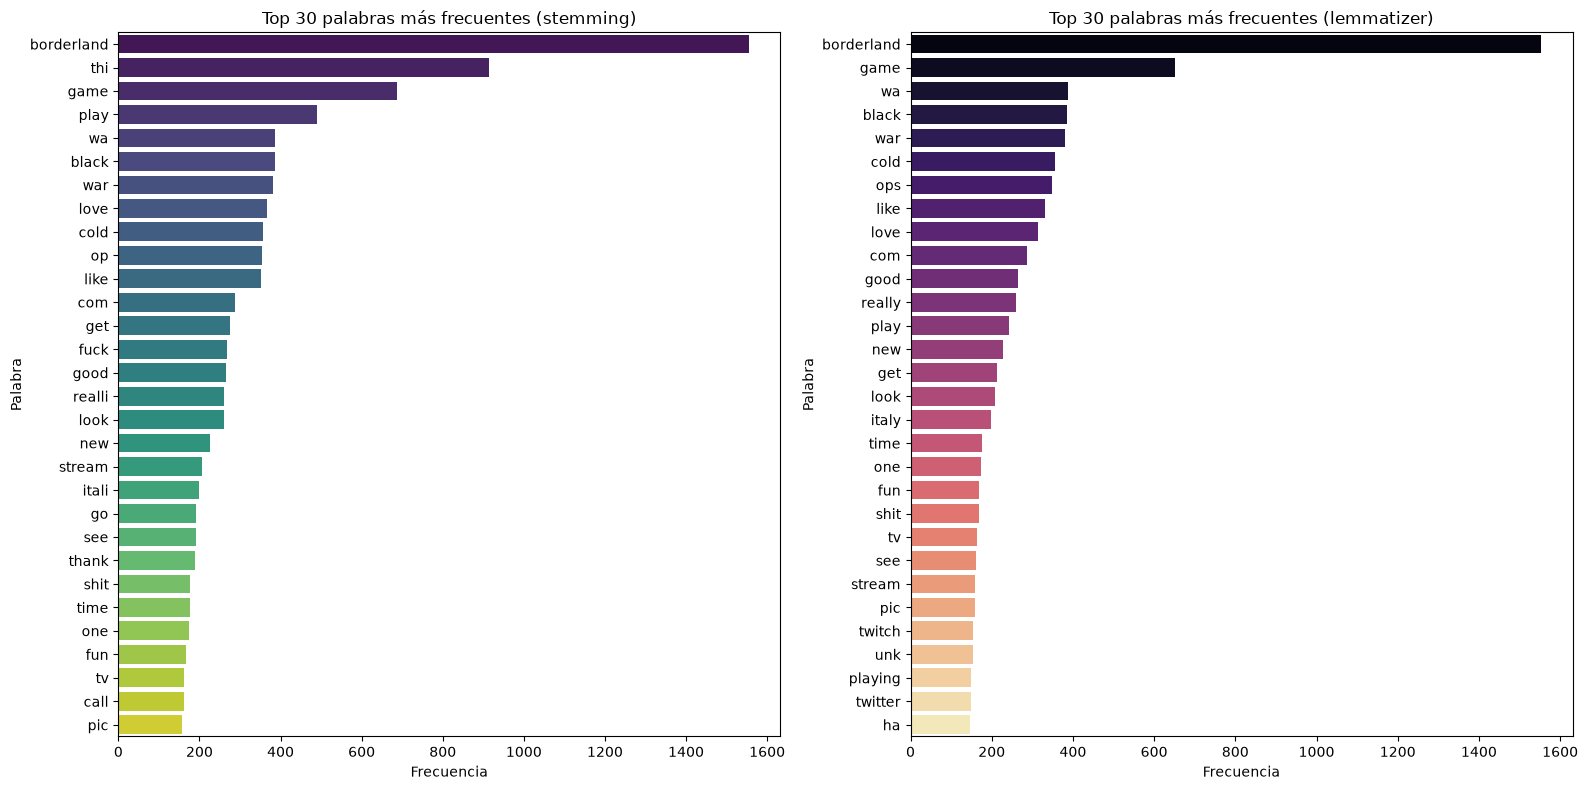

In [14]:
vectorizer_stem = CountVectorizer(ngram_range=(1, 1), binary=False)
features_train_stem = vectorizer_stem.fit_transform(df_data['ProcessedText_stem'].tolist())
vocab_stem = vectorizer_stem.get_feature_names_out()
dist_stem = list(np.array(features_train_stem.sum(axis=0)).reshape(-1,))
word_freq_stem = sorted(list(zip(vocab_stem, dist_stem)), key=lambda x: x[1], reverse=True)

top_n = 30
top_stem = word_freq_stem[:top_n]
top_lemma = word_freq[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Izquierda: stemming
words_stem, freqs_stem = zip(*top_stem)
sns.barplot(x=list(freqs_stem), y=list(words_stem), hue=list(words_stem),
            palette='viridis', legend=False, ax=axes[0])
axes[0].set_title(f'Top {top_n} palabras más frecuentes (stemming)')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Palabra')

# Derecha: lemmatizer
words_lemma, freqs_lemma = zip(*top_lemma)
sns.barplot(x=list(freqs_lemma), y=list(words_lemma), hue=list(words_lemma),
            palette='magma', legend=False, ax=axes[1])
axes[1].set_title(f'Top {top_n} palabras más frecuentes (lemmatizer)')
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('Palabra')

plt.tight_layout()
plt.show()

### Nube de palabras (WordCloud)

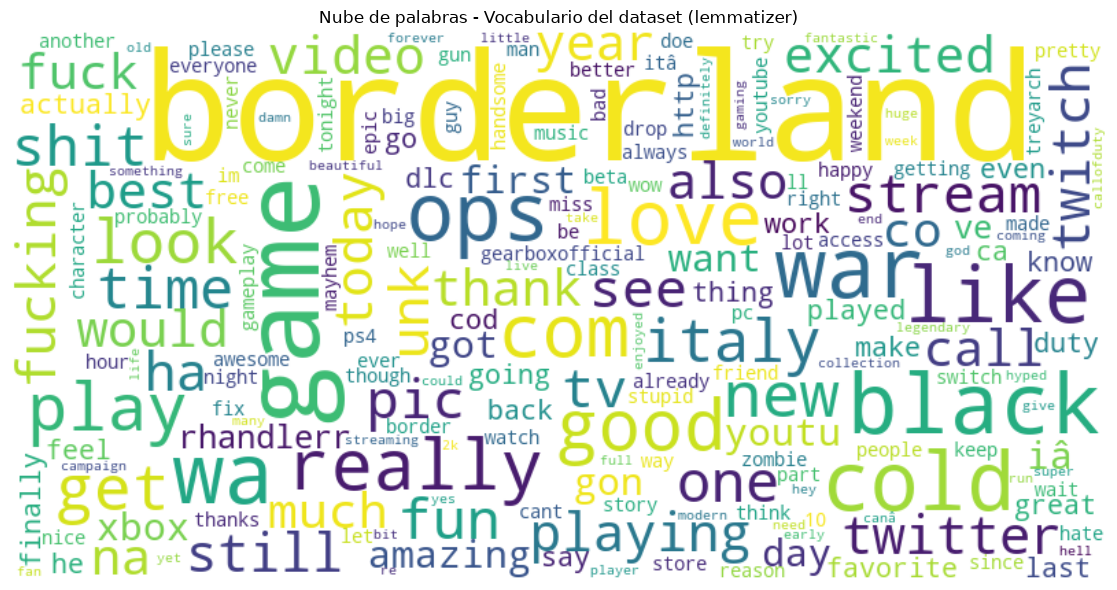

In [15]:
from wordcloud import WordCloud

word_freq2 = dict(zip(vocab, dist))

# Generar la WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq2)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Vocabulario del dataset (lemmatizer)')
plt.tight_layout()
plt.show()